# CNN and ResNet on 10% of Quantum Corrosion Data

This notebook trains and evaluates two 1D convolutional baselines on a 10% stratified subsample of the corrosion dataset:

- a small custom CNN
- a ResNet-style 1D model

It uses the existing `data/splits/*.json` files, loads processed spectrograms from `data/processed/*.npy`, extracts the same raw-IQ spectral features used in the project pipeline, reduces them with `StandardScaler + PCA(256)`, and evaluates classification plus regression heads.

In [8]:
import json
import math
import re
import time
import warnings
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from contextlib import nullcontext
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import kurtosis as scipy_kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler

import pennylane as qml

warnings.filterwarnings("ignore")

BASE_DIR = Path("/home/sammarv/quantum_corrosion")
DATA_DIR = BASE_DIR / "data"
SPLITS_DIR = DATA_DIR / "splits"
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = BASE_DIR / "results" / "cnn_resnet_10pct"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
TRAIN_FRAC = 0.10
VAL_FRAC = 0.10
TEST_FRAC = 0.10
TRAIN_FRAC = 1.0
VAL_FRAC = 1.0
TEST_FRAC = 1.0
N_CLASSES = 5
PCA_DIM = 256
N_WORKERS = 4
BATCH_SIZE = 32
EPOCHS = 12
PATIENCE = 4
ALPHA = 0.30

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IQ_FILES = {
    0: RAW_DIR / "0.5" / "0.5.iq",
    1: RAW_DIR / "1" / "1.iq",
    2: RAW_DIR / "1.5" / "1.5.iq",
    3: RAW_DIR / "2" / "2.iq",
    4: RAW_DIR / "2.5" / "2.5.iq",
}
GRAM_VALUES = {0: 0.5, 1: 1.0, 2: 1.5, 3: 2.0, 4: 2.5}

FFT_SIZE = 4096
N_STACKS = 16
OVERLAP = 0.25
HOP = int(FFT_SIZE * (1 - OVERLAP))
SAMPLES_PER_IMG = N_STACKS * HOP + (FFT_SIZE - HOP)
WIN = np.hanning(FFT_SIZE).astype(np.float32)

print(f"Device: {DEVICE}")
print(f"Output dir: {OUT_DIR}")
print(f"Feature pipeline: FFT_SIZE={FFT_SIZE}, N_STACKS={N_STACKS}, SAMPLES_PER_IMG={SAMPLES_PER_IMG}")

Device: cuda
Output dir: /home/sammarv/quantum_corrosion/results/cnn_resnet_10pct
Feature pipeline: FFT_SIZE=4096, N_STACKS=16, SAMPLES_PER_IMG=50176


In [10]:
def _get_img_idx(path):
    match = re.search(r"img(\d+)", str(path))
    return int(match.group(1)) if match else 0


def load_split(name):
    with open(SPLITS_DIR / f"{name}.json") as handle:
        return json.load(handle)


def subsample_items(items, fraction, seed=SEED):
    if fraction >= 1.0:
        return list(items)
    rng = np.random.default_rng(seed)
    labels = np.array([item["label"] for item in items])
    selected = []
    for cls in sorted(np.unique(labels)):
        class_idx = np.where(labels == cls)[0]
        keep = max(1, int(len(class_idx) * fraction))
        chosen = rng.choice(class_idx, size=keep, replace=False)
        selected.extend(chosen.tolist())
    selected = sorted(selected)
    return [items[i] for i in selected]


def build_iqs():
    iqs = {}
    for label, path in IQ_FILES.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing IQ file: {path}")
        iqs[label] = np.memmap(str(path), dtype="complex64", mode="r")
        print(f"  class {label}: {len(iqs[label]) // 1_000_000:.0f}M samples")
    return iqs


def extract_one(iq, img_idx):
    start = img_idx * SAMPLES_PER_IMG
    end = start + SAMPLES_PER_IMG
    if end > len(iq):
        return None

    frames = np.empty((N_STACKS, FFT_SIZE), dtype="complex64")
    for stack_idx in range(N_STACKS):
        frame_start = start + stack_idx * HOP
        frames[stack_idx] = iq[frame_start:frame_start + FFT_SIZE]

    spec = np.fft.fftshift(np.fft.fft(frames * WIN, axis=1), axes=1)
    mag = np.abs(spec).astype(np.float32)

    psd_mean = mag.mean(axis=0)
    psd_db = 20.0 * np.log10(psd_mean + 1e-12)
    psd_256 = psd_db.reshape(256, 16).mean(axis=1)

    psd_var = mag.var(axis=0)
    var_256 = np.log1p(psd_var.reshape(256, 16).mean(axis=1))

    total_power = float(psd_mean.sum())
    freqs = np.arange(FFT_SIZE, dtype=np.float32)
    centroid = float((freqs * psd_mean).sum() / (psd_mean.sum() + 1e-12))
    bandwidth = float(np.sqrt(((freqs - centroid) ** 2 * psd_mean).sum() / (psd_mean.sum() + 1e-12)))
    log_psd = np.log(psd_mean + 1e-12)
    flatness = float(np.exp(log_psd.mean()) / (psd_mean.mean() + 1e-12))
    p = psd_mean / (psd_mean.sum() + 1e-12)
    entropy = float(-np.sum(p * np.log(p + 1e-12)))
    frame_power = mag.sum(axis=1)
    power_var = float(frame_power.var())
    power_skew = float(skew(frame_power))
    power_kurt = float(scipy_kurtosis(frame_power))
    stats = np.array([
        total_power, centroid, bandwidth, flatness,
        entropy, power_var, power_skew, power_kurt,
    ], dtype=np.float32)

    phase = np.angle(spec).astype(np.float32)
    phase_mean_std = float(np.std(phase.mean(axis=0)))
    phase_var_mean = float(phase.var(axis=1).mean())
    inst_freq = np.diff(np.unwrap(phase, axis=0), axis=0)
    if_mean = float(inst_freq.mean())
    if_std = float(inst_freq.std())
    i_pwr = float((frames.real ** 2).mean())
    q_pwr = float((frames.imag ** 2).mean())
    iq_imbalance = float(i_pwr / (q_pwr + 1e-12))
    iq_corr = float(np.corrcoef(frames.real.reshape(-1)[:2048], frames.imag.reshape(-1)[:2048])[0, 1])
    amp = np.abs(frames.reshape(-1)[:4096])
    amp_kurt = float(scipy_kurtosis(amp))
    amp_skew = float(skew(amp))
    phase_feats = np.array([
        phase_mean_std, phase_var_mean, if_mean, if_std,
        iq_imbalance, iq_corr, amp_kurt, amp_skew,
    ], dtype=np.float32)

    return np.concatenate([psd_256, var_256, stats, phase_feats]).astype(np.float32)


def extract_features_parallel(meta_list, iqs, n_workers=N_WORKERS):
    feats = [None] * len(meta_list)
    labels = [None] * len(meta_list)
    start_time = time.time()

    def worker(index, record):
        label = int(record["label"])
        img_idx = _get_img_idx(record["path"])
        return index, extract_one(iqs[label], img_idx), label

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(worker, idx, record): idx for idx, record in enumerate(meta_list)}
        completed = 0
        for future in as_completed(futures):
            idx, feature_vector, label = future.result()
            feats[idx] = feature_vector
            labels[idx] = label
            completed += 1
            if completed % 100 == 0 or completed == len(meta_list):
                elapsed = time.time() - start_time
                rate = elapsed / max(1, completed)
                eta = rate * (len(meta_list) - completed)
                print(f"  {completed}/{len(meta_list)}  elapsed={elapsed:.0f}s  ETA={eta:.0f}s")

    valid = [(feature_vector, label) for feature_vector, label in zip(feats, labels) if feature_vector is not None]
    X = np.stack([item[0] for item in valid])
    y = np.array([item[1] for item in valid], dtype=np.int64)
    print(f"  extracted {len(valid)} samples in {time.time() - start_time:.1f}s  shape={X.shape}")
    return X, y


def load_or_extract(meta, split_name, iqs):
    cache_dir = OUT_DIR / "feature_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_X = cache_dir / f"{split_name}_X.npy"
    cache_y = cache_dir / f"{split_name}_y.npy"
    if cache_X.exists() and cache_y.exists():
        X = np.load(cache_X)
        y = np.load(cache_y)
        print(f"  [{split_name}] loaded cache: {X.shape}")
        return X, y
    print(f"  [{split_name}] extracting {len(meta)} samples with {N_WORKERS} workers")
    X, y = extract_features_parallel(meta, iqs)
    np.save(cache_X, X)
    np.save(cache_y, y)
    return X, y


print("[Data]")
train_meta_full = load_split("train")
val_meta_full = load_split("val")
test_meta_full = load_split("test")

train_meta = subsample_items(train_meta_full, TRAIN_FRAC)
val_meta = subsample_items(val_meta_full, VAL_FRAC)
test_meta = subsample_items(test_meta_full, TEST_FRAC)

print(f"  train: {len(train_meta)}  val: {len(val_meta)}  test: {len(test_meta)}")
print(f"  train labels: {Counter(item['label'] for item in train_meta)}")

iqs = build_iqs()

X_train_raw, y_train = load_or_extract(train_meta, "train_full", iqs)
X_val_raw, y_val = load_or_extract(val_meta, "val_full", iqs)
X_test_raw, y_test = load_or_extract(test_meta, "test_full", iqs)

X_train_raw = np.nan_to_num(X_train_raw, nan=0.0, posinf=0.0, neginf=0.0)
X_val_raw = np.nan_to_num(X_val_raw, nan=0.0, posinf=0.0, neginf=0.0)
X_test_raw = np.nan_to_num(X_test_raw, nan=0.0, posinf=0.0, neginf=0.0)

print(f"  raw feature dim: {X_train_raw.shape[1]}")

[Data]
  train: 3698  val: 1233  test: 1233
  train labels: Counter({4: 812, 3: 795, 0: 731, 2: 698, 1: 662})
  class 0: 480M samples
  class 1: 434M samples
  class 2: 458M samples
  class 3: 522M samples
  class 4: 534M samples
  [train_full] extracting 3698 samples with 4 workers
  100/3698  elapsed=0s  ETA=13s
  200/3698  elapsed=1s  ETA=12s
  300/3698  elapsed=1s  ETA=12s
  400/3698  elapsed=1s  ETA=11s
  500/3698  elapsed=2s  ETA=10s
  600/3698  elapsed=2s  ETA=10s
  700/3698  elapsed=2s  ETA=10s
  800/3698  elapsed=3s  ETA=9s
  900/3698  elapsed=3s  ETA=9s
  1000/3698  elapsed=3s  ETA=9s
  1100/3698  elapsed=4s  ETA=9s
  1200/3698  elapsed=4s  ETA=8s
  1300/3698  elapsed=4s  ETA=8s
  1400/3698  elapsed=5s  ETA=8s
  1500/3698  elapsed=5s  ETA=7s
  1600/3698  elapsed=5s  ETA=7s
  1700/3698  elapsed=6s  ETA=7s
  1800/3698  elapsed=6s  ETA=6s
  1900/3698  elapsed=6s  ETA=6s
  2000/3698  elapsed=7s  ETA=6s
  2100/3698  elapsed=7s  ETA=5s
  2200/3698  elapsed=7s  ETA=5s
  2300/3698  e

In [11]:
print("[Preprocess]")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

pca = PCA(n_components=PCA_DIM, random_state=SEED)
X_train = pca.fit_transform(X_train_scaled)
X_val = pca.transform(X_val_scaled)
X_test = pca.transform(X_test_scaled)

print(f"  PCA({PCA_DIM}) variance explained: {pca.explained_variance_ratio_.sum():.3f}")

joblib.dump(scaler, OUT_DIR / "scaler.pkl")
joblib.dump(pca, OUT_DIR / "pca_256.pkl")

CLASS_NAMES = ["0.5g", "1.0g", "1.5g", "2.0g", "2.5g"]

def to_tensor_dataset(X, y):
    X_tensor = torch.from_numpy(X.astype(np.float32)).unsqueeze(1)
    y_tensor = torch.from_numpy(y.astype(np.int64))
    grams = torch.from_numpy(np.array([GRAM_VALUES[int(label)] for label in y], dtype=np.float32))
    return TensorDataset(X_tensor, y_tensor, grams)


def make_balanced_sampler(labels):
    counts = Counter(labels.tolist())
    weights = [1.0 / counts[int(label)] for label in labels]
    return WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double), num_samples=len(weights), replacement=True)


train_ds = to_tensor_dataset(X_train, y_train)
val_ds = to_tensor_dataset(X_val, y_val)
test_ds = to_tensor_dataset(X_test, y_test)

train_sampler = make_balanced_sampler(y_train)
print(f"  train tensor shape: {X_train.shape}")

[Preprocess]
  PCA(256) variance explained: 0.824
  train tensor shape: (3698, 256)


In [12]:
def build_loaders(batch_size=BATCH_SIZE):
    loader_kwargs = dict(num_workers=2, pin_memory=torch.cuda.is_available())
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler, drop_last=True, **loader_kwargs)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, **loader_kwargs)
    return train_loader, val_loader, test_loader


def train_one_epoch(model, loader, optimizer, clf_loss_fn, reg_loss_fn, alpha=ALPHA, device=DEVICE):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    amp_context = torch.autocast(device_type="cuda", dtype=torch.float16) if device.type == "cuda" else nullcontext()
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    for features, labels, grams in loader:
        features = features.to(device)
        labels = labels.to(device)
        grams = grams.to(device)
        optimizer.zero_grad(set_to_none=True)
        with amp_context:
            logits, gram_pred = model(features)
            loss = (1 - alpha) * clf_loss_fn(logits, labels) + alpha * reg_loss_fn(gram_pred, grams)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_seen += batch_size
    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate_model(model, loader, device=DEVICE):
    model.eval()
    amp_context = torch.autocast(device_type="cuda", dtype=torch.float16) if device.type == "cuda" else nullcontext()
    all_true = []
    all_pred = []
    all_gram_true = []
    all_gram_pred = []
    total_loss = 0.0
    clf_loss_fn = nn.CrossEntropyLoss()
    reg_loss_fn = nn.HuberLoss(delta=0.5)
    for features, labels, grams in loader:
        features = features.to(device)
        labels = labels.to(device)
        grams = grams.to(device)
        with amp_context:
            logits, gram_pred = model(features)
            loss = 0.7 * clf_loss_fn(logits, labels) + 0.3 * reg_loss_fn(gram_pred, grams)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        all_true.extend(labels.cpu().tolist())
        all_pred.extend(preds.cpu().tolist())
        all_gram_true.extend(grams.cpu().tolist())
        all_gram_pred.extend(gram_pred.cpu().tolist())
    acc = accuracy_score(all_true, all_pred)
    f1 = f1_score(all_true, all_pred, average="macro")
    mae = mean_absolute_error(all_gram_true, all_gram_pred)
    r2 = r2_score(all_gram_true, all_gram_pred)
    return {
        "loss": total_loss / len(loader.dataset),
        "acc": acc,
        "f1": f1,
        "mae": mae,
        "r2": r2,
        "y_true": all_true,
        "y_pred": all_pred,
        "g_true": all_gram_true,
        "g_pred": all_gram_pred,
    }


def plot_confusion_matrix(y_true, y_pred, title, file_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(OUT_DIR / file_name, dpi=200, bbox_inches="tight")
    plt.show()


class CNN1D(nn.Module):
    def __init__(self, input_length=PCA_DIM, n_classes=N_CLASSES):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Dropout(0.10),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Dropout(0.10),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
        )
        self.classifier = nn.Linear(128, n_classes)
        self.regressor = nn.Linear(128, 1)

    def forward(self, x):
        z = self.backbone(x)
        z = self.shared(z)
        logits = self.classifier(z)
        grams = self.regressor(z).squeeze(1)
        return logits, grams


print("  shared utilities and CNN1D model are ready")

  shared utilities and CNN1D model are ready


In [ ]:
class BasicBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.10):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + residual
        out = self.relu(out)
        return out


class ResNet1D(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )
        self.stage1 = nn.Sequential(
            BasicBlock1D(64, 64),
            BasicBlock1D(64, 64),
        )
        self.stage2 = nn.Sequential(
            BasicBlock1D(64, 128, stride=2),
            BasicBlock1D(128, 128),
        )
        self.stage3 = nn.Sequential(
            BasicBlock1D(128, 256, stride=2),
            BasicBlock1D(256, 256),
        )
        self.stage4 = nn.Sequential(
            BasicBlock1D(256, 256, stride=2),
            BasicBlock1D(256, 256),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
        )
        self.classifier = nn.Linear(128, n_classes)
        self.regressor = nn.Linear(128, 1)

    def forward(self, x):
        z = self.stem(x)
        z = self.stage1(z)
        z = self.stage2(z)
        z = self.stage3(z)
        z = self.stage4(z)
        z = self.pool(z)
        z = self.shared(z)
        logits = self.classifier(z)
        grams = self.regressor(z).squeeze(1)
        return logits, grams


print("  ResNet1D model is ready")

In [13]:
print("[Train CNN]")
train_loader, val_loader, test_loader = build_loaders()

cnn_model = CNN1D().to(DEVICE)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"  trainable params: {cnn_params:,}")

counts = Counter(y_train.tolist())
class_weights = torch.tensor([1.0 / counts[i] for i in range(N_CLASSES)], dtype=torch.float32, device=DEVICE)
class_weights = class_weights / class_weights.sum() * N_CLASSES

cnn_clf_loss = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.10)
cnn_reg_loss = nn.HuberLoss(delta=0.5)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=3e-3, weight_decay=1e-4)
cnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=EPOCHS)
cnn_ckpt = OUT_DIR / "cnn_best.pt"

cnn_history = []
best_cnn_val_acc = -1.0
best_cnn_epoch = 0
best_cnn_state = None
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        cnn_model,
        train_loader,
        cnn_optimizer,
        cnn_clf_loss,
        cnn_reg_loss,
        alpha=ALPHA,
        device=DEVICE,
    )
    val_metrics = evaluate_model(cnn_model, val_loader, device=DEVICE)
    cnn_scheduler.step()

    cnn_history.append({
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "val_loss": float(val_metrics["loss"]),
        "val_acc": float(val_metrics["acc"]),
        "val_f1": float(val_metrics["f1"]),
        "val_mae": float(val_metrics["mae"]),
        "val_r2": float(val_metrics["r2"]),
    })

    if val_metrics["acc"] > best_cnn_val_acc:
        best_cnn_val_acc = float(val_metrics["acc"])
        best_cnn_epoch = epoch
        best_cnn_state = {key: value.detach().cpu().clone() for key, value in cnn_model.state_dict().items()}
        torch.save(best_cnn_state, cnn_ckpt)
        no_improve = 0
    else:
        no_improve += 1

    print(
        f"  epoch {epoch:02d}/{EPOCHS}  "
        f"tr_loss={train_loss:.4f}  tr_acc={train_acc:.4f}  "
        f"val_acc={val_metrics['acc']:.4f}  val_f1={val_metrics['f1']:.4f}  "
        f"val_mae={val_metrics['mae']:.4f}  best={best_cnn_val_acc:.4f}"
    )

    if no_improve >= PATIENCE:
        print(f"  early stopping at epoch {epoch} (patience={PATIENCE})")
        break

with open(OUT_DIR / "cnn_history.json", "w") as handle:
    json.dump(cnn_history, handle, indent=2)

print(f"  best CNN val_acc={best_cnn_val_acc:.4f} at epoch {best_cnn_epoch}")
print(f"  checkpoint saved to {cnn_ckpt}")

[Train CNN]
  trainable params: 52,998
  epoch 01/12  tr_loss=0.8464  tr_acc=0.5508  val_acc=0.2255  val_f1=0.1406  val_mae=0.8268  best=0.2255
  epoch 02/12  tr_loss=0.6167  tr_acc=0.7505  val_acc=0.4663  val_f1=0.3391  val_mae=0.3743  best=0.4663
  epoch 03/12  tr_loss=0.5408  tr_acc=0.8220  val_acc=0.8808  val_f1=0.8758  val_mae=0.2869  best=0.8808
  epoch 04/12  tr_loss=0.5040  tr_acc=0.8625  val_acc=0.8654  val_f1=0.8605  val_mae=0.4065  best=0.8808
  epoch 05/12  tr_loss=0.4981  tr_acc=0.8598  val_acc=0.8735  val_f1=0.8649  val_mae=0.2551  best=0.8808
  epoch 06/12  tr_loss=0.4867  tr_acc=0.8601  val_acc=0.9019  val_f1=0.8978  val_mae=0.2380  best=0.9019
  epoch 07/12  tr_loss=0.4581  tr_acc=0.8938  val_acc=0.9051  val_f1=0.9004  val_mae=0.2400  best=0.9051
  epoch 08/12  tr_loss=0.4584  tr_acc=0.8918  val_acc=0.8978  val_f1=0.8931  val_mae=0.2209  best=0.9051
  epoch 09/12  tr_loss=0.4477  tr_acc=0.9022  val_acc=0.8954  val_f1=0.8911  val_mae=0.2406  best=0.9051
  epoch 10/12  t

[Evaluate CNN]
  val  acc=0.9148  f1=0.9112  mae=0.2146  r2=0.7816
  test acc=0.8962  f1=0.8900  mae=0.2090  r2=0.8050

CNN classification report - validation
              precision    recall  f1-score   support

        0.5g       0.96      0.88      0.91       244
        1.0g       0.85      0.85      0.85       220
        1.5g       0.86      0.86      0.86       233
        2.0g       1.00      1.00      1.00       265
        2.5g       0.90      0.96      0.93       271

    accuracy                           0.91      1233
   macro avg       0.91      0.91      0.91      1233
weighted avg       0.92      0.91      0.91      1233


CNN classification report - test
              precision    recall  f1-score   support

        0.5g       0.94      0.91      0.93       244
        1.0g       0.83      0.73      0.78       221
        1.5g       0.77      0.85      0.81       232
        2.0g       1.00      1.00      1.00       265
        2.5g       0.92      0.95      0.94    

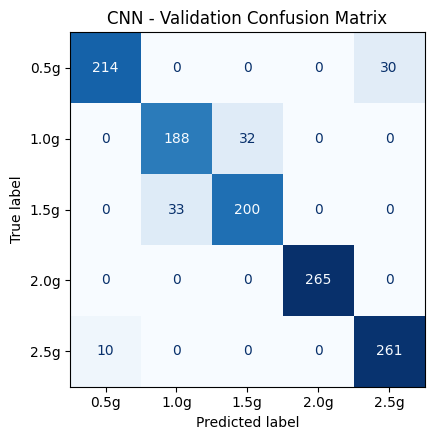

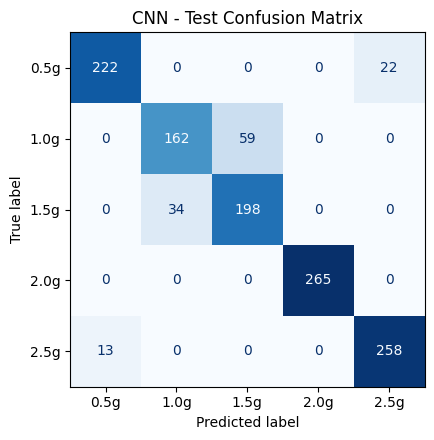

  CNN evaluation complete


In [14]:
print("[Evaluate CNN]")
cnn_model.load_state_dict(torch.load(cnn_ckpt, map_location=DEVICE))
cnn_model.to(DEVICE)

cnn_val_metrics = evaluate_model(cnn_model, val_loader, device=DEVICE)
cnn_test_metrics = evaluate_model(cnn_model, test_loader, device=DEVICE)

print(f"  val  acc={cnn_val_metrics['acc']:.4f}  f1={cnn_val_metrics['f1']:.4f}  mae={cnn_val_metrics['mae']:.4f}  r2={cnn_val_metrics['r2']:.4f}")
print(f"  test acc={cnn_test_metrics['acc']:.4f}  f1={cnn_test_metrics['f1']:.4f}  mae={cnn_test_metrics['mae']:.4f}  r2={cnn_test_metrics['r2']:.4f}")

print("\nCNN classification report - validation")
print(classification_report(cnn_val_metrics["y_true"], cnn_val_metrics["y_pred"], target_names=CLASS_NAMES))
print("\nCNN classification report - test")
print(classification_report(cnn_test_metrics["y_true"], cnn_test_metrics["y_pred"], target_names=CLASS_NAMES))

plot_confusion_matrix(cnn_val_metrics["y_true"], cnn_val_metrics["y_pred"], "CNN - Validation Confusion Matrix", "cnn_val_confusion.png")
plot_confusion_matrix(cnn_test_metrics["y_true"], cnn_test_metrics["y_pred"], "CNN - Test Confusion Matrix", "cnn_test_confusion.png")

results = {}
results["cnn"] = {
    "best_val_acc": float(best_cnn_val_acc),
    "best_epoch": int(best_cnn_epoch),
    "val_acc": float(cnn_val_metrics["acc"]),
    "val_f1": float(cnn_val_metrics["f1"]),
    "val_mae": float(cnn_val_metrics["mae"]),
    "val_r2": float(cnn_val_metrics["r2"]),
    "test_acc": float(cnn_test_metrics["acc"]),
    "test_f1": float(cnn_test_metrics["f1"]),
    "test_mae": float(cnn_test_metrics["mae"]),
    "test_r2": float(cnn_test_metrics["r2"]),
}
print("  CNN evaluation complete")

In [ ]:
print("[Train ResNet]")
resnet_model = ResNet1D().to(DEVICE)
resnet_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"  trainable params: {resnet_params:,}")

resnet_clf_loss = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.10)
resnet_reg_loss = nn.HuberLoss(delta=0.5)
resnet_optimizer = torch.optim.AdamW(resnet_model.parameters(), lr=3e-3, weight_decay=1e-4)
resnet_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(resnet_optimizer, T_max=EPOCHS)
resnet_ckpt = OUT_DIR / "resnet_best.pt"

resnet_history = []
best_resnet_val_acc = -1.0
best_resnet_epoch = 0
best_resnet_state = None
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        resnet_model,
        train_loader,
        resnet_optimizer,
        resnet_clf_loss,
        resnet_reg_loss,
        alpha=ALPHA,
        device=DEVICE,
    )
    val_metrics = evaluate_model(resnet_model, val_loader, device=DEVICE)
    resnet_scheduler.step()

    resnet_history.append({
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "val_loss": float(val_metrics["loss"]),
        "val_acc": float(val_metrics["acc"]),
        "val_f1": float(val_metrics["f1"]),
        "val_mae": float(val_metrics["mae"]),
        "val_r2": float(val_metrics["r2"]),
    })

    if val_metrics["acc"] > best_resnet_val_acc:
        best_resnet_val_acc = float(val_metrics["acc"])
        best_resnet_epoch = epoch
        best_resnet_state = {key: value.detach().cpu().clone() for key, value in resnet_model.state_dict().items()}
        torch.save(best_resnet_state, resnet_ckpt)
        no_improve = 0
    else:
        no_improve += 1

    print(
        f"  epoch {epoch:02d}/{EPOCHS}  "
        f"tr_loss={train_loss:.4f}  tr_acc={train_acc:.4f}  "
        f"val_acc={val_metrics['acc']:.4f}  val_f1={val_metrics['f1']:.4f}  "
        f"val_mae={val_metrics['mae']:.4f}  best={best_resnet_val_acc:.4f}"
    )

    if no_improve >= PATIENCE:
        print(f"  early stopping at epoch {epoch} (patience={PATIENCE})")
        break

with open(OUT_DIR / "resnet_history.json", "w") as handle:
    json.dump(resnet_history, handle, indent=2)

print(f"  best ResNet val_acc={best_resnet_val_acc:.4f} at epoch {best_resnet_epoch}")
print(f"  checkpoint saved to {resnet_ckpt}")

In [ ]:
print("[Evaluate ResNet]")
resnet_model.load_state_dict(torch.load(resnet_ckpt, map_location=DEVICE))
resnet_model.to(DEVICE)

resnet_val_metrics = evaluate_model(resnet_model, val_loader, device=DEVICE)
resnet_test_metrics = evaluate_model(resnet_model, test_loader, device=DEVICE)

print(f"  val  acc={resnet_val_metrics['acc']:.4f}  f1={resnet_val_metrics['f1']:.4f}  mae={resnet_val_metrics['mae']:.4f}  r2={resnet_val_metrics['r2']:.4f}")
print(f"  test acc={resnet_test_metrics['acc']:.4f}  f1={resnet_test_metrics['f1']:.4f}  mae={resnet_test_metrics['mae']:.4f}  r2={resnet_test_metrics['r2']:.4f}")

print("\nResNet classification report - validation")
print(classification_report(resnet_val_metrics["y_true"], resnet_val_metrics["y_pred"], target_names=CLASS_NAMES))
print("\nResNet classification report - test")
print(classification_report(resnet_test_metrics["y_true"], resnet_test_metrics["y_pred"], target_names=CLASS_NAMES))

plot_confusion_matrix(resnet_val_metrics["y_true"], resnet_val_metrics["y_pred"], "ResNet - Validation Confusion Matrix", "resnet_val_confusion.png")
plot_confusion_matrix(resnet_test_metrics["y_true"], resnet_test_metrics["y_pred"], "ResNet - Test Confusion Matrix", "resnet_test_confusion.png")

results["resnet"] = {
    "best_val_acc": float(best_resnet_val_acc),
    "best_epoch": int(best_resnet_epoch),
    "val_acc": float(resnet_val_metrics["acc"]),
    "val_f1": float(resnet_val_metrics["f1"]),
    "val_mae": float(resnet_val_metrics["mae"]),
    "val_r2": float(resnet_val_metrics["r2"]),
    "test_acc": float(resnet_test_metrics["acc"]),
    "test_f1": float(resnet_test_metrics["f1"]),
    "test_mae": float(resnet_test_metrics["mae"]),
    "test_r2": float(resnet_test_metrics["r2"]),
}
print("  ResNet evaluation complete")

In [ ]:
print("[Compare Models]")

for name, item in results.items():
    print(
        f"  {name:7s} | best_val_acc={item['best_val_acc']:.4f} | "
        f"test_acc={item['test_acc']:.4f} | test_f1={item['test_f1']:.4f} | "
        f"test_mae={item['test_mae']:.4f} | test_r2={item['test_r2']:.4f}"
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metric_keys = [
    ("test_acc", "Test Accuracy"),
    ("test_f1", "Test Macro F1"),
    ("test_mae", "Test MAE (g)"),
    ("test_r2", "Test R²"),
]
model_names = list(results.keys())
for axis, (metric_key, metric_title) in zip(axes.flat, metric_keys):
    values = [results[model][metric_key] for model in model_names]
    axis.bar(model_names, values, color=["#1f77b4", "#ff7f0e"][: len(model_names)])
    axis.set_title(metric_title)
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "comparison_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, history, title in [
    (axes[0], cnn_history, "CNN Training Curves"),
    (axes[1], resnet_history, "ResNet Training Curves"),
]:
    epochs_axis = [row["epoch"] for row in history]
    train_acc = [row["train_acc"] for row in history]
    val_acc = [row["val_acc"] for row in history]
    val_loss = [row["val_loss"] for row in history]
    axis.plot(epochs_axis, train_acc, label="train acc", linewidth=2)
    axis.plot(epochs_axis, val_acc, label="val acc", linewidth=2)
    axis.plot(epochs_axis, val_loss, label="val loss", linewidth=2)
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

summary = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "device": str(DEVICE),
    "train_fraction": TRAIN_FRAC,
    "val_fraction": VAL_FRAC,
    "test_fraction": TEST_FRAC,
    "raw_feature_dim": int(X_train_raw.shape[1]),
    "pca_dim": PCA_DIM,
    "results": results,
}
with open(OUT_DIR / "summary.json", "w") as handle:
    json.dump(summary, handle, indent=2)

print(f"  summary saved to {OUT_DIR / 'summary.json'}")
print(f"  figures saved to {OUT_DIR}")